# MATH GR5360 Final Project — Master Pipeline

One-click amalgamated notebook for the project-facing trend-following workflow. It imports the shared engine, runs the diagnostics layer to locate the time-scale of the inefficiency, executes the trend-following walk-forward engine, and computes the OOS and full-sample TF metrics.


In [1]:
MARKET_SELECT = 'TY'
QUICK_TEST = True
WALKFORWARD_MODE = 'tf'
RUN_EXTENDED_SURFACE = False

DATA_INTERVAL_MINUTES = 5
DATA_FILE_OVERRIDE = r'/Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv'
# Note: the repo currently contains TY-1minHLV.csv but no valid BTC-1minHLV.csv.


In [2]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    apply_columbia_theme,
    choose_tf_story_configuration,
    default_tf_grid,
    get_market,
    load_ohlc,
    performance_from_ledger,
    prepare_analysis_frame,
    run_backtest,
    run_diagnostics,
    validate_ohlc,
    walk_forward,
    walk_forward_surface,
)

apply_columbia_theme()
MARKET = get_market(MARKET_SELECT)
DATA_PATH = DATA_FILE_OVERRIDE or str(PROJECT_ROOT / 'data')
print(f"Market: {MARKET.ticker} - {MARKET.name} ({MARKET.exchange})")
print(f"PV=${MARKET.PV:,}  Slippage=${MARKET.slpg}  E0=${MARKET.E0:,.0f}")


Market: TY - 10-Year Treasury (CBOT-CME)
PV=$1,000  Slippage=$18.625  E0=$100,000


In [3]:
DEFAULT_T_VALUES = [1, 2, 3, 4, 5, 6]
DEFAULT_TAU_VALUES = [1, 2, 3, 4]


def _grid_signature(grid: dict[str, np.ndarray]) -> tuple[tuple[str, tuple[float, ...]], ...]:
    signature = []
    for key in sorted(grid):
        values = []
        for value in np.asarray(grid[key]).tolist():
            if isinstance(value, (int, np.integer)):
                values.append(int(value))
            else:
                values.append(float(value))
        signature.append((key, tuple(values)))
    return tuple(signature)


def ensure_analysis_state(force: bool = False) -> None:
    global MARKET, full_df, validation, analysis_df, tf_grid, _analysis_market

    MARKET = get_market(MARKET_SELECT)
    if force or globals().get('_analysis_market') != MARKET_SELECT or 'analysis_df' not in globals():
        full_df = load_ohlc(DATA_PATH, MARKET_SELECT, fallback_synthetic=False, bar_minutes=DATA_INTERVAL_MINUTES)
        validation = validate_ohlc(full_df)
        analysis_df = prepare_analysis_frame(full_df, MARKET_SELECT)
        _analysis_market = MARKET_SELECT

    tf_grid = default_tf_grid(MARKET_SELECT, quick=QUICK_TEST, bar_minutes=DATA_INTERVAL_MINUTES)


def ensure_diagnostics_state(force: bool = False) -> None:
    global diagnostics_bundle, vr_price_df, regime_table, trend_profile, _diagnostics_market

    ensure_analysis_state(force=force)
    if force or globals().get('_diagnostics_market') != MARKET_SELECT or 'diagnostics_bundle' not in globals():
        diagnostics_bundle = run_diagnostics(analysis_df, MARKET_SELECT)
        vr_price_df = diagnostics_bundle['vr_price_df']
        regime_table = diagnostics_bundle['regime_table']
        trend_profile = diagnostics_bundle['trend_profile']
        _diagnostics_market = MARKET_SELECT


def ensure_walkforward_state(force: bool = False) -> None:
    global wf_bundle, wf_params, wf_equity, wf_ledger, wf_results, _wf_signature

    ensure_analysis_state(force=force)
    signature = (
        MARKET_SELECT,
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        4,
        1,
        _grid_signature(tf_grid),
    )

    if force or globals().get('_wf_signature') != signature or 'wf_bundle' not in globals():
        wf_bundle = walk_forward(
            analysis_df,
            MARKET_SELECT,
            mode=WALKFORWARD_MODE,
            tf_grid=tf_grid,
            T_years=4,
            tau_quarters=1,
            quick=QUICK_TEST,
            verbose=True,
        )
        _wf_signature = signature

    wf_params = wf_bundle['params']
    wf_equity = wf_bundle['equity']
    wf_ledger = wf_bundle['ledger']
    wf_results = wf_params


def _tf_full_sample_config() -> dict[str, object]:
    return choose_tf_story_configuration(MARKET_SELECT, tf_grid=tf_grid, params_df=wf_params)


def ensure_full_sample_state(force: bool = False) -> None:
    global modal_cfg, full_sample_result, oos_metrics, full_sample_metrics, _full_sample_signature

    ensure_walkforward_state(force=force)
    ensure_diagnostics_state(force=force)
    candidate = _tf_full_sample_config()

    signature = (MARKET_SELECT, tuple(sorted(candidate.items())))
    if force or globals().get('_full_sample_signature') != signature or 'full_sample_result' not in globals():
        modal_cfg = dict(candidate)
        full_sample_result = run_backtest(
            analysis_df,
            MARKET_SELECT,
            modal_cfg['family'],
            {k: v for k, v in modal_cfg.items() if k != 'family'},
        )
        oos_metrics = performance_from_ledger(
            wf_ledger,
            wf_equity['OOS_Equity'].values if len(wf_equity) else np.array([MARKET.E0]),
            MARKET_SELECT,
        )
        full_sample_metrics = performance_from_ledger(
            full_sample_result['Ledger'],
            full_sample_result['Equity'],
            MARKET_SELECT,
        )
        _full_sample_signature = signature


ensure_diagnostics_state(force=True)
print(validation)
print('Diagnostics complete. The strategy workflow below is fixed to trend-following only.')
print(trend_profile['narrative'])
regime_table.head()


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv


{'n_bars': 863887, 'start': Timestamp('1983-01-03 08:05:00'), 'end': Timestamp('2026-04-10 14:00:00'), 'years': 43.266255989048595, 'issues': [], 'is_valid': True}
Diagnostics complete. The strategy workflow below is fixed to trend-following only.
TY looks weak or mixed at short horizons, so the treasury story should emphasise that any trend-following inefficiency is a slower multi-session effect rather than a fast daily one.


,time_scale,k,VR,VR_Z2_robust,VR_p2,VR_sig,VR_pattern,push_scale,PR_rho_mean,PR_rho_sig_any,Recommendation
0,10min,2,0.956449,-0.022468,0.982075,False,mean_revert,NaN,NaN,NaN,TF-baseline (no rejection)
1,20min,4,0.937137,-0.017414,0.986106,False,mean_revert,NaN,NaN,NaN,TF-baseline (no rejection)
2,40min,8,0.930096,-0.013125,0.989528,False,mean_revert,NaN,NaN,NaN,TF-baseline (no rejection)
3,1.0hr,12,0.930641,-0.010804,0.991380,False,mean_revert,1.0hr,0.433766,True,TF-baseline (no rejection)
4,2.0hr,24,0.930760,-0.008135,0.993509,False,mean_revert,2.0hr,0.328571,True,TF-baseline (no rejection)


In [4]:
ensure_full_sample_state(force=True)

print()
print('MASTER SUMMARY')
print('-' * 72)
print(f"Periods: {len(wf_params)}  |  OOS ledger rows: {len(wf_ledger)}")
print(f"TF config: {modal_cfg}")
pd.DataFrame([oos_metrics, full_sample_metrics], index=['OOS', 'Full Sample'])


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv


Walk-Forward [TY] mode=tf: IS=4yr (80,640 bars), OOS=1Q (5,040 bars), cost=1.00x


  P1 TF IS_obj=+5.084 OOS_obj=+0.653 votes(tf=1, mr=0)


  P2 TF IS_obj=+5.171 OOS_obj=+2.095 votes(tf=1, mr=0)


  P3 TF IS_obj=+5.842 OOS_obj=+0.325 votes(tf=1, mr=0)


...

  P153 TF IS_obj=+5.560 OOS_obj=-0.035 votes(tf=1, mr=0)


  P154 TF IS_obj=+4.817 OOS_obj=-0.677 votes(tf=1, mr=0)


  P155 TF IS_obj=+5.704 OOS_obj=+0.884 votes(tf=1, mr=0)
✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv



MASTER SUMMARY
------------------------------------------------------------------------
Periods: 155  |  OOS ledger rows: 395
TF config: {'family': 'tf', 'L': 1440, 'S': 0.01}


,Total Profit,Return %,Ann. Return %,Ann. Volatility %,Sharpe Ratio,Max Drawdown $,Max Drawdown %,Avg Drawdown $,CDD (α=0.05) $,DD Duration (bars),...,Total Trades,Win Rate %,Avg Winner $,Avg Loser $,Win/Loss Ratio,Profit Factor,Gross Profit $,Gross Loss $,Avg Trade PnL $,Avg Duration (bars)
OOS,68335.515625,68.335516,1.451238,4.637422,0.312941,15864.703125,10.964860,5657.405394,13270.678993,179179,...,395,33.164557,1264.739146,-896.742898,1.410370,0.699843,165680.828125,236740.1250,-179.896954,965.265823
Full Sample,87864.718750,87.864719,1.542908,3.795500,0.406510,17186.468750,10.124396,5216.570534,14984.545400,229835,...,724,41.298343,1171.908549,-617.731618,1.897116,1.334677,350400.656250,262535.9375,121.360109,641.444751


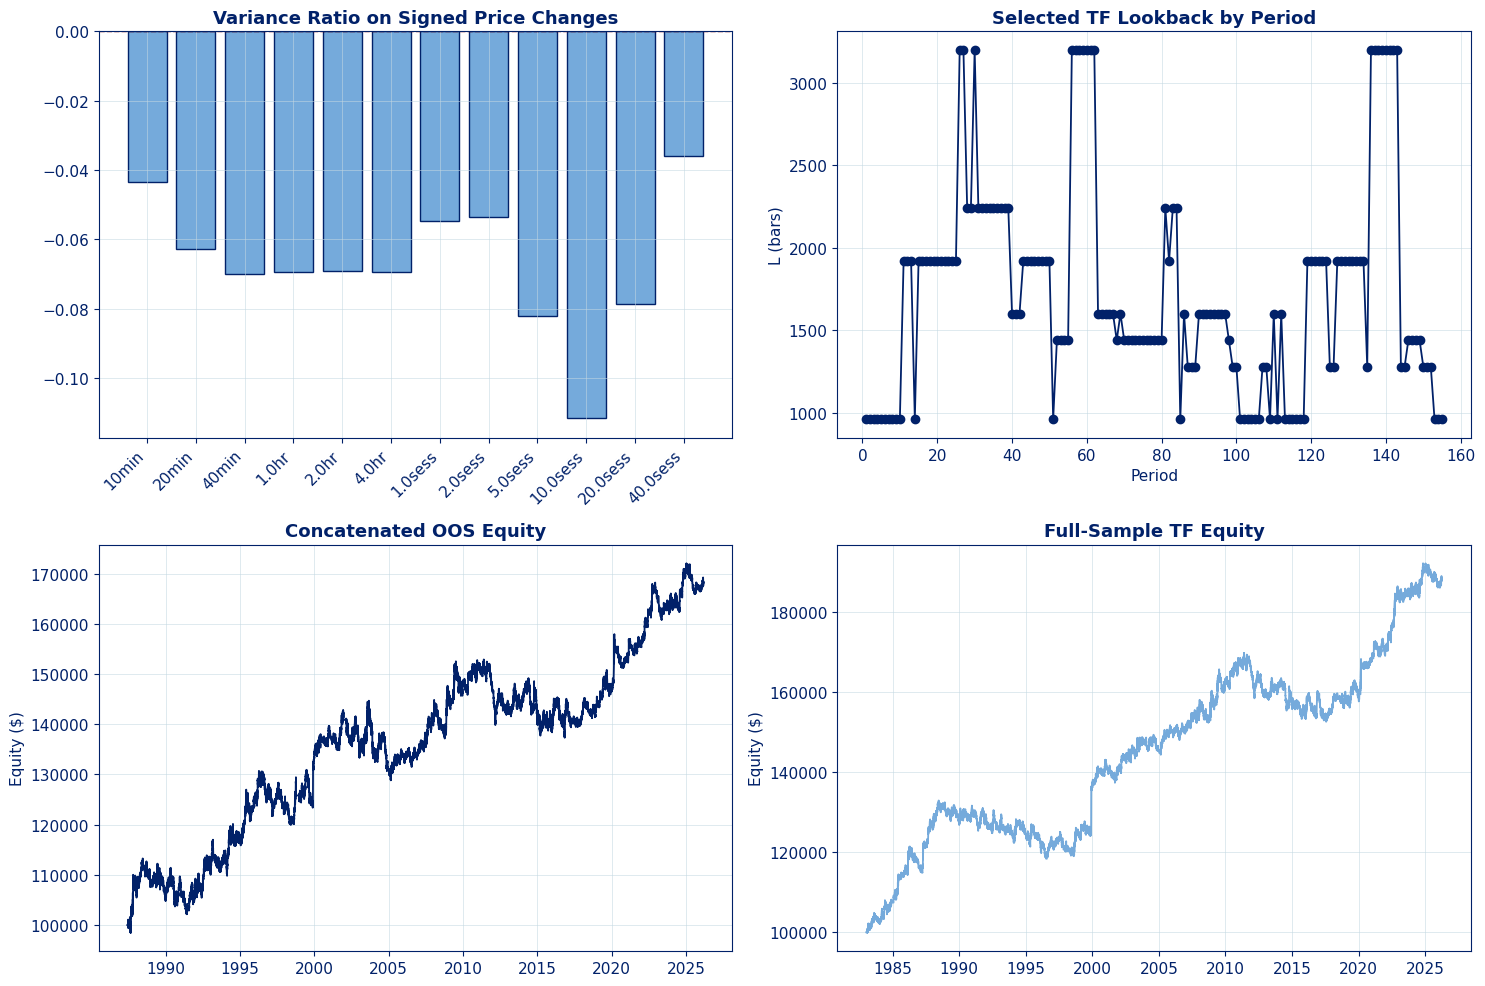

In [5]:
ensure_full_sample_state()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(range(len(vr_price_df)), vr_price_df['VR'] - 1.0, color=COLUMBIA_CORE, edgecolor=COLUMBIA_NAVY)
axes[0, 0].axhline(0.0, color=COLUMBIA_RED, linestyle='--', linewidth=1)
axes[0, 0].set_xticks(range(len(vr_price_df)))
axes[0, 0].set_xticklabels(vr_price_df['time_scale'], rotation=45, ha='right')
axes[0, 0].set_title('Variance Ratio on Signed Price Changes')

if len(wf_params) and 'L' in wf_params:
    axes[0, 1].plot(wf_params['Period'], wf_params['L'], marker='o', color=COLUMBIA_NAVY)
    axes[0, 1].set_title('Selected TF Lookback by Period')
    axes[0, 1].set_xlabel('Period')
    axes[0, 1].set_ylabel('L (bars)')
else:
    axes[0, 1].text(0.5, 0.5, 'No TF parameter history generated', ha='center', va='center')
    axes[0, 1].set_axis_off()

if len(wf_equity):
    axes[1, 0].plot(wf_equity.index, wf_equity['OOS_Equity'], color=COLUMBIA_NAVY)
    axes[1, 0].set_title('Concatenated OOS Equity')
    axes[1, 0].set_ylabel('Equity ($)')
else:
    axes[1, 0].text(0.5, 0.5, 'No OOS equity generated', ha='center', va='center')
    axes[1, 0].set_axis_off()

axes[1, 1].plot(analysis_df.index, full_sample_result['Equity'], color=COLUMBIA_CORE)
axes[1, 1].set_title('Full-Sample TF Equity')
axes[1, 1].set_ylabel('Equity ($)')

plt.tight_layout()
plt.show()


In [6]:
if RUN_EXTENDED_SURFACE:
    ensure_analysis_state()
    surface_df = walk_forward_surface(
        analysis_df,
        MARKET_SELECT,
        mode=WALKFORWARD_MODE,
        tf_grid=tf_grid,
        T_values=DEFAULT_T_VALUES,
        tau_values=DEFAULT_TAU_VALUES,
        quick=QUICK_TEST,
        verbose=False,
    )
    surface_valid = surface_df[~surface_df['error']].copy()
    surface_valid
